## Data Consolidation

In [19]:
import re, glob, pandas as pd
from datetime import date

SRC = 'nowcasting/Month-Over-MonthPercentChange-*.csv' # input dir
OUT = 'nowcasting/cleveland_fed_nowcast_consolidated.csv' # output dir

def target_ym(fname): # extracts target month and year for CPI
    y, m = re.match(r'Month-Over-MonthPercentChange-(\d{4})-(\d{1,2})\.csv', fname).groups()
    return int(y), int(m)

def assign_dates(labels, target_year, target_month): # assigns a year to the data. CSVs have no year
    """MM/DD labels have no year; infer it by rolling forward whenever the
    month drops (a year-boundary crossing), anchored on the target month."""
    first_month = int(labels[0].split('/')[0])
    year = target_year - 1 if first_month - target_month > 6 else target_year
    dates, prev_month = [], None
    for lab in labels:
        mm, dd = (int(x) for x in lab.split('/'))
        if prev_month is not None and mm < prev_month:
            year += 1
        dates.append(date(year, mm, dd))
        prev_month = mm
    return dates

frames = []
for f in sorted(glob.glob(SRC)):
    ty, tm = target_ym(f.split('/')[-1])
    df = pd.read_csv(f).dropna(subset=['Label'])
    df['date'] = assign_dates(df['Label'].tolist(), ty, tm)
    df['target_month'] = f'{ty:04d}-{tm:02d}'
    df['months_ahead'] = (ty * 12 + tm) - (pd.to_datetime(df['date']).dt.year * 12
                                            + pd.to_datetime(df['date']).dt.month)
    frames.append(df[['date', 'target_month', 'months_ahead', 'CPI Inflation',
                       'Core CPI Inflation', 'PCE Inflation', 'Core PCE Inflation']])

panel = pd.concat(frames, ignore_index=True)

# Drop exact duplicate (date, target_month) rows, keeping the first.
panel = panel.drop_duplicates(subset=['date', 'target_month'], keep='first')

# Drop rows with no data at all in any of the four series.
value_cols = ['CPI Inflation', 'Core CPI Inflation', 'PCE Inflation', 'Core PCE Inflation']
panel = panel.dropna(subset=value_cols, how='all')

panel = panel.sort_values(['date', 'target_month']).reset_index(drop=True)
panel.rename(columns={'date': 'update_date'}, inplace=True)
panel.to_csv(OUT, index=False)

## Plotting

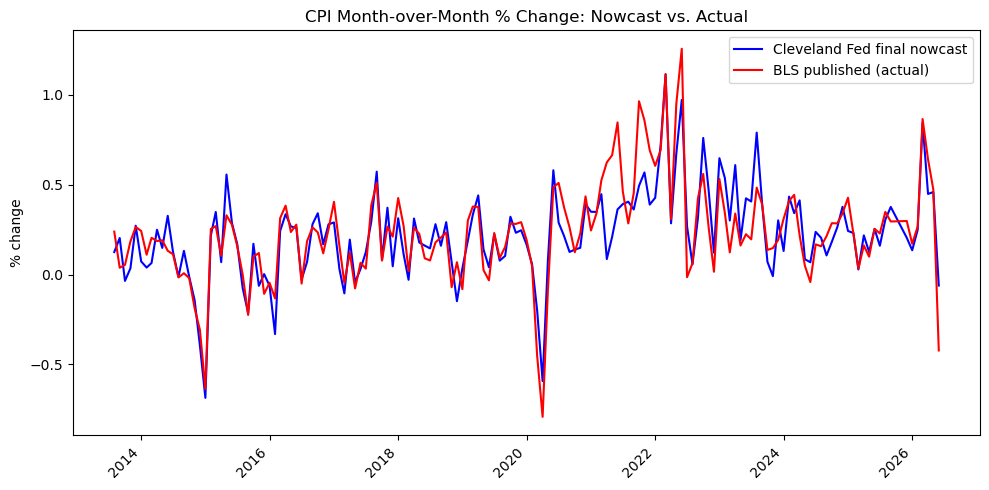

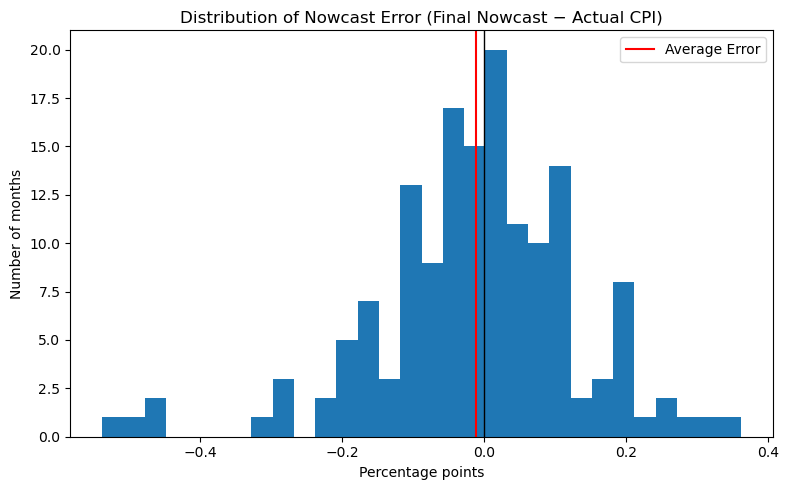

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

panel = pd.read_csv(r'nowcasting/cleveland_fed_nowcast_consolidated.csv', parse_dates=['update_date'])

# Final nowcast per target month = the last update recorded before release.
final = (panel.sort_values('update_date')
               .groupby('target_month')
               .last()[['CPI Inflation', 'Core CPI Inflation']]
               .rename(columns={'CPI Inflation': 'nowcast_cpi',
                                 'Core CPI Inflation': 'nowcast_core_cpi'}))

# Actual MoM % change from the BLS index levels since they measure the actual CPI, not the change
def mom_pct(path, col):
    df = pd.read_csv(path, parse_dates=['observation_date'])
    df['month'] = df['observation_date'].dt.strftime('%Y-%m')
    df[f'actual_{col}'] = df[col].pct_change(fill_method=None) * 100
    return df.set_index('month')[f'actual_{col}']

actual_cpi = mom_pct('inflation_data/CPIAUCSL.csv', 'CPIAUCSL')

compare = final.join(actual_cpi.rename('actual_cpi')).join(actual_core.rename('actual_core_cpi')).dropna()
compare.index = pd.to_datetime(compare.index)  # <-- fixes the squished x-axis
compare['error_cpi'] = compare['nowcast_cpi'] - compare['actual_cpi']
compare['error_core_cpi'] = compare['nowcast_core_cpi'] - compare['actual_core_cpi']
compare.to_csv('nowcast_vs_actual.csv')

# Chart 1: nowcast vs. actual over time
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(compare.index, compare['nowcast_cpi'], color='blue', label='Cleveland Fed final nowcast')
ax.plot(compare.index, compare['actual_cpi'], color='red', label='BLS published (actual)')
ax.set_title('CPI Month-over-Month % Change: Nowcast vs. Actual')
ax.set_ylabel('% change')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()
#fig.savefig('nowcast_vs_actual_timeseries.png', dpi=150)

# Chart 2: error distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(compare['error_cpi'], bins=30)
ax.axvline(0, color='black', linewidth=1)
ax.axvline(compare['error_cpi'].mean(), color='red', label='Average Error')
ax.set_title('Distribution of Nowcast Error (Final Nowcast − Actual CPI)')
ax.set_xlabel('Percentage points')
ax.set_ylabel('Number of months')
ax.legend()
fig.tight_layout()
#fig.savefig('nowcast_error_distribution.png', dpi=150)

In [21]:
print("Nowcast June 2026:", compare['nowcast_cpi'].iloc[-1])
print("Actual June 2026:", compare['actual_cpi'].iloc[-1])

Nowcast June 2026: -0.0612913952296244
Actual June 2026: -0.42248165303806484


[*********************100%***********************]  1 of 1 completed

Calm-regime daily drift: +0.00032, daily vol: 0.02142 (n=1299)


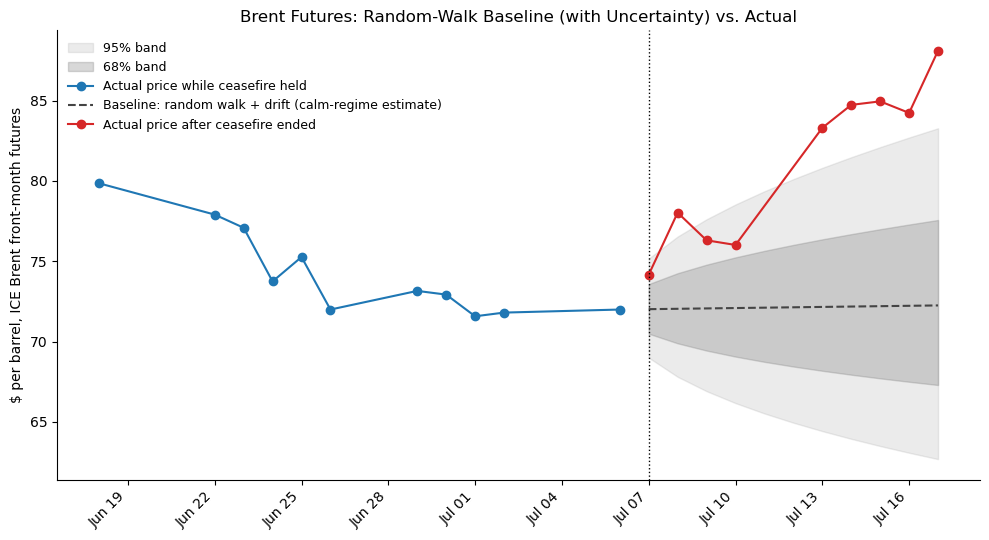

In [23]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Pull Brent futures (ICE) daily closes ---
brent = yf.download('BZ=F', start='2021-01-01', end='2026-07-18')['Close'].squeeze()
brent.index = pd.to_datetime(brent.index)
log_ret = np.log(brent / brent.shift(1)).dropna()

# --- Known event dates ---
mou_signed = pd.Timestamp('2026-06-18')
ceasefire_breaks = pd.Timestamp('2026-07-07')

# --- Estimation window: exclude known shock periods (2025 war, 2026 war/Hormuz
# closure) from the "normal regime" used to estimate drift and volatility ---
known_shock_windows = [
    ('2025-06-10', '2025-06-30'),   # Twelve-Day War
    ('2026-02-25', '2026-06-17'),   # 2026 Iran war through MoU signing
]
mask = pd.Series(True, index=log_ret.index)
for start, end in known_shock_windows:
    mask &= ~((log_ret.index >= start) & (log_ret.index <= end))
calm_returns = log_ret[mask]

mu = calm_returns.mean()      # daily drift, log-return terms
sigma = calm_returns.std()    # daily volatility, log-return terms
print(f'Calm-regime daily drift: {mu:+.5f}, daily vol: {sigma:.5f} (n={len(calm_returns)})')

# --- Actual price while ceasefire held vs. after it broke down ---
ceasefire_period = brent.loc[mou_signed:ceasefire_breaks - pd.Timedelta(days=1)]
actual_after_end = brent.loc[ceasefire_breaks:]

# --- Random-walk-with-drift baseline + confidence band, compounding forward
# in log space from the last ceasefire-era price ---
last_price = ceasefire_period.iloc[-1]
future_dates = pd.date_range(ceasefire_period.index[-1] + pd.Timedelta(days=1),
                              brent.index[-1], freq='D')
h = np.arange(1, len(future_dates) + 1) # dates after ceasefire end
baseline = last_price * np.exp(mu * h)
band_width = sigma * np.sqrt(h)          # std dev of cumulative log return grows with sqrt(h)
upper_1sd = last_price * np.exp(mu * h + band_width) # exponents since returns were logged
lower_1sd = last_price * np.exp(mu * h - band_width)
upper_2sd = last_price * np.exp(mu * h + 2 * band_width) # ranges are mean +- z-score * width
lower_2sd = last_price * np.exp(mu * h - 2 * band_width)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.fill_between(future_dates, lower_2sd, upper_2sd, color='#7f7f7f', alpha=0.15, label='95% band')
ax.fill_between(future_dates, lower_1sd, upper_1sd, color='#7f7f7f', alpha=0.3, label='68% band')
ax.plot(ceasefire_period.index, ceasefire_period.values, marker='o', color='#1f77b4',
        label='Actual price while ceasefire held')
ax.plot(future_dates, baseline, linestyle='--', color='#444444',
        label='Baseline: random walk + drift (calm-regime estimate)')
ax.plot(actual_after_end.index, actual_after_end.values, marker='o', color='#d62728',
        label='Actual price after ceasefire ended')

ax.axvline(ceasefire_breaks, color='black', linestyle=':', linewidth=1)
ax.annotate('Ceasefire ends:\ntanker attacked', xy=(ceasefire_breaks, brent.max()),
            xytext=(4, 0), textcoords='offset points', fontsize=9)

ax.set_title('Brent Futures: Random-Walk Baseline (with Uncertainty) vs. Actual', fontsize=12)
ax.set_ylabel('$ per barrel, ICE Brent front-month futures')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(loc='upper left', frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()